In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('2107_electrical_data.csv', parse_dates=['measured_on'])

print('Shape:', df.shape)
print('Rango temporal:', df['measured_on'].min(), '→', df['measured_on'].max())
df.head()

Shape: (632952, 120)
Rango temporal: 2017-11-01 00:00:00 → 2023-11-07 23:55:00


,measured_on,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584,inv_02_dc_voltage_inv_149585,inv_02_ac_current_inv_149586,inv_02_ac_voltage_inv_149587,...,inv_23_dc_current_inv_149689,inv_23_dc_voltage_inv_149690,inv_23_ac_current_inv_149691,inv_23_ac_voltage_inv_149692,inv_23_ac_power_inv_149693,inv_24_dc_current_inv_149694,inv_24_dc_voltage_inv_149695,inv_24_ac_current_inv_149696,inv_24_ac_voltage_inv_149697,inv_24_ac_power_inv_149698
0,2017-11-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2017-11-01 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017-11-01 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2017-11-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2017-11-01 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
nulos_pct = (nulos / len(df) * 100).round(3)
resumen_nulos = pd.DataFrame({'nulos': nulos, '%': nulos_pct})
print('Columnas con nulos:', len(nulos))
resumen_nulos

Columnas con nulos: 114


,nulos,%
inv_13_ac_voltage_inv_149642,1728,0.273
inv_13_ac_power_inv_149643,1728,0.273
inv_19_dc_current_inv_149669,1728,0.273
inv_18_ac_power_inv_149668,1728,0.273
inv_18_ac_voltage_inv_149667,1728,0.273
...,...,...
inv_02_dc_voltage_inv_149585,366,0.058
inv_02_ac_current_inv_149586,366,0.058
inv_02_ac_voltage_inv_149587,366,0.058
inv_02_ac_power_inv_149588,366,0.058


In [3]:
print('Filas duplicadas:', df.duplicated().sum())

# Buscar columna con typo
cols_atipicas = [c for c in df.columns if 'iinv' in c]
print('Columna con typo:', cols_atipicas)

Filas duplicadas: 0
Columna con typo: ['inv_15_ac_power_iinv_149653']


In [4]:
import re

# Extraer el número de inversor de cada columna
nulos_por_inversor = {}
for col in nulos.index:
    match = re.match(r'inv_(\d+)_', col)
    if match:
        inv_num = match.group(1)
        nulos_por_inversor[inv_num] = nulos_por_inversor.get(inv_num, 0) + nulos[col]

pd.Series(nulos_por_inversor).sort_values(ascending=False)

13    8640
19    8640
10    8640
09    8640
12    8640
11    8640
04    8640
06    8640
07    8640
08    8640
20    8640
21    8640
23    8640
24    8640
22    8640
14    8640
15    8640
16    8640
17    8640
18    8640
05    6912
01    1830
02    1830
dtype: int64

count    632952.000000
mean        156.322502
std         230.963511
min           0.000000
25%           0.000000
50%           0.000000
75%         291.599750
max         721.609000
Name: total_ac_power, dtype: float64


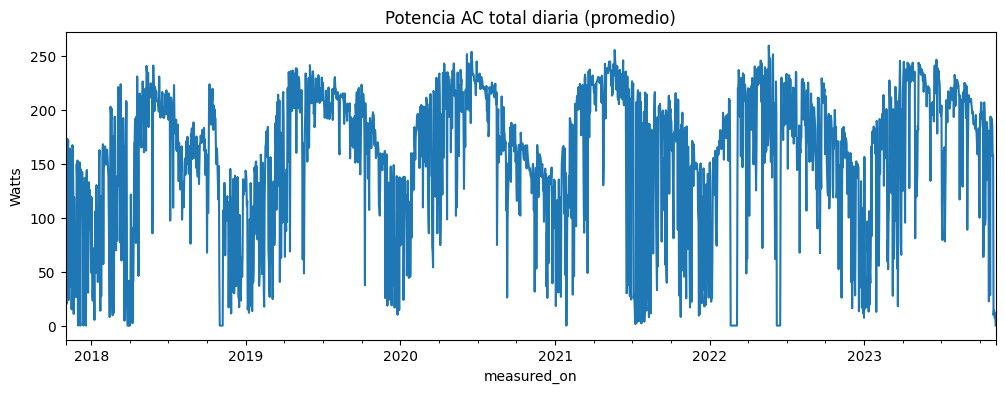

In [5]:
power_cols = [c for c in df.columns if 'ac_power' in c]
df['total_ac_power'] = df[power_cols].sum(axis=1, min_count=1)

print(df['total_ac_power'].describe())

plt.figure(figsize=(12,4))
df.set_index('measured_on')['total_ac_power'].resample('1D').mean().plot()
plt.title('Potencia AC total diaria (promedio)')
plt.ylabel('Watts')
plt.show()

In [7]:
# Preparación de datos
df = df.rename(columns={'inv_15_ac_power_iinv_149653': 'inv_15_ac_power_inv_149653'})
df = df.fillna(0)  # nulos = inversor apagado

df['hour'] = df['measured_on'].dt.hour
df['month'] = df['measured_on'].dt.month
df['year'] = df['measured_on'].dt.year

print('Nulos restantes:', df.isnull().sum().sum())
df[['measured_on','hour','month','year','total_ac_power']].head()

Nulos restantes: 0


,measured_on,hour,month,year,total_ac_power
0,2017-11-01 00:00:00,0,11,2017,0.0
1,2017-11-01 00:05:00,0,11,2017,0.0
2,2017-11-01 00:10:00,0,11,2017,0.0
3,2017-11-01 00:15:00,0,11,2017,0.0
4,2017-11-01 00:20:00,0,11,2017,0.0


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Filtrar solo horas con generación (de noche todo es 0, no aporta)
df_luz = df[df['total_ac_power'] > 0].copy()

# Tomar muestra para que entrene rápido
df_sample = df_luz.sample(n=min(80000, len(df_luz)), random_state=42)

# Features: corrientes/voltajes DC y AC de entrada + variables temporales
feature_cols = [c for c in df.columns if ('dc_current' in c or 'dc_voltage' in c or 'ac_current' in c or 'ac_voltage' in c)]
feature_cols += ['hour', 'month']

X = df_sample[feature_cols].values
y = df_sample['total_ac_power'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Filas de entrenamiento:', X_train.shape[0])
print('Filas de prueba:', X_test.shape[0])


Filas de entrenamiento: 64000
Filas de prueba: 16000


In [11]:
import numpy as np

# Modelo 1: Regresión Lineal (baseline)
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
pred_lin = lin_model.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))
r2_lin = r2_score(y_test, pred_lin)

# Modelo 2: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print(f'Regresion Lineal -> RMSE: {rmse_lin:.2f}, R2: {r2_lin:.4f}')
print(f'Random Forest    -> RMSE: {rmse_rf:.2f}, R2: {r2_rf:.4f}')

Regresion Lineal -> RMSE: 7.00, R2: 0.9991
Random Forest    -> RMSE: 8.65, R2: 0.9987


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import re

# Construir perfil de desempeño por inversor (excluyendo la columna agregada)
power_cols_clean = [c for c in df.columns if 'ac_power' in c and c != 'total_ac_power']
perfiles = []

for col in power_cols_clean:
    match = re.match(r'(inv_\d+)_', col)
    inv_id = match.group(1)
    energia_total = df[col].sum()
    potencia_media = df.loc[df[col] > 0, col].mean()
    pct_cero = (df[col] == 0).mean() * 100
    perfiles.append({'inversor': inv_id, 'energia_total': energia_total,
                      'potencia_media': potencia_media, 'pct_cero': pct_cero})

df_perfiles = pd.DataFrame(perfiles).set_index('inversor')

scaler = StandardScaler()
X_perfil = scaler.fit_transform(df_perfiles)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_perfiles['cluster'] = kmeans.fit_predict(X_perfil)

df_perfiles.sort_values('cluster')

,energia_total,potencia_media,pct_cero,cluster
inversor,,,,
inv_12,4311149.107,14.598674,53.343855,0
inv_20,4449836.520,14.883691,52.765139,0
inv_15,4247916.797,14.557831,53.899190,0
inv_14,4217751.365,14.713018,54.709362,0
inv_13,4357344.511,14.859666,53.672158,0
inv_23,4152162.647,14.690277,55.344639,0
inv_11,4412860.146,14.961384,53.400890,0
inv_10,4197021.015,14.596659,54.572701,0
inv_09,4306017.294,14.658782,53.590478,0


In [14]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error

# Serie semanal de energía generada
serie_semanal = df.set_index('measured_on')['total_ac_power'].resample('1W').sum()
serie_semanal = serie_semanal.iloc[1:-1]  # quitar semanas parciales en los extremos

# Split temporal: último año como test
n_test = 52
train_ts = serie_semanal.iloc[:-n_test]
test_ts = serie_semanal.iloc[-n_test:]

# Modelo Holt-Winters (tendencia + estacionalidad anual)
hw_model = ExponentialSmoothing(train_ts, trend='add', seasonal='add', seasonal_periods=52).fit()
pred_hw = hw_model.forecast(n_test)

# Baseline ingenuo estacional (mismo valor que hace 52 semanas)
baseline = train_ts.iloc[-n_test:].values

mae_hw = mean_absolute_error(test_ts, pred_hw)
mae_baseline = mean_absolute_error(test_ts, baseline)

print(f'MAE Baseline ingenuo : {mae_baseline:,.0f}')
print(f'MAE Holt-Winters     : {mae_hw:,.0f}')


MAE Baseline ingenuo : 81,013
MAE Holt-Winters     : 53,016


In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error

# Serie semanal de energía generada
serie_semanal = df.set_index('measured_on')['total_ac_power'].resample('1W').sum()
serie_semanal = serie_semanal.iloc[1:-1]  # quitar semanas parciales en los extremos

# Split temporal: último año como test
n_test = 52
train_ts = serie_semanal.iloc[:-n_test]
test_ts = serie_semanal.iloc[-n_test:]

# Modelo Holt-Winters (tendencia + estacionalidad anual)
hw_model = ExponentialSmoothing(train_ts, trend='add', seasonal='add', seasonal_periods=52).fit()
pred_hw = hw_model.forecast(n_test)

# Baseline ingenuo estacional (mismo valor que hace 52 semanas)
baseline = train_ts.iloc[-n_test:].values

mae_hw = mean_absolute_error(test_ts, pred_hw)
mae_baseline = mean_absolute_error(test_ts, baseline)

print(f'MAE Baseline ingenuo : {mae_baseline:,.0f}')
print(f'MAE Holt-Winters     : {mae_hw:,.0f}')

MAE Baseline ingenuo : 81,013
MAE Holt-Winters     : 53,016


 Evaluación general

**Supervisado:** Regresión Lineal (RMSE 7.00, R² 0.9991) y Random Forest (RMSE 8.65, R² 0.9987) predicen `total_ac_power` con precisión casi perfecta a partir de las señales DC/AC de entrada. La Regresión Lineal superó ligeramente al Random Forest, indicando que la relación entre las variables de entrada y la potencia total es mayormente lineal.

**No supervisado:** El clustering (K-Means, k=3) sobre el perfil de los 24 inversores identificó un grupo de menor desempeño (inversores 07, 06, 04, 02, entre otros) con menor energía total generada y mayor porcentaje de tiempo en cero durante horas de luz — candidatos a revisión de mantenimiento.

**Forecasting:** Holt-Winters (MAE 53,016) superó al baseline ingenuo estacional (MAE 81,013), una mejora de ~35%, aprovechando la tendencia y estacionalidad anual de la generación solar.

 Discusión

- El alto R² de los modelos supervisados se explica porque `total_ac_power` es esencialmente una función determinística de las señales de entrada (suma agregada), más que un patrón oculto complejo — de ahí que incluso el modelo lineal funcione casi perfecto.
- El análisis no supervisado aportó valor diagnóstico que el modelo supervisado no captura: mientras el supervisado predice bien la potencia total, el clustering revela qué inversores individuales están rindiendo por debajo del resto de la flota.
- El hallazgo de nulos variables por inversor (114 columnas afectadas, con valores desde 366 hasta 1728 registros faltantes) sugiere que los apagones no fueron simultáneos para toda la planta, sino que ciertos inversores (13, 19, 10, 09, entre otros) tuvieron periodos de desconexión más prolongados — coincide parcialmente con los inversores de menor desempeño detectados en el clustering.
- Holt-Winters mejora sobre el baseline pero sigue siendo un modelo univariado: no incorpora variables externas como irradiancia solar o temperatura ambiente, que explicarían mejor la variabilidad no capturada.
- **Limitación principal:** la imputación de nulos con 0 asume que todo valor faltante corresponde a un inversor apagado, supuesto razonable pero no verificable con la información disponible.

 Conclusiones

1. La potencia AC total de la planta puede predecirse con altísima precisión (R² > 0.999) a partir únicamente de las señales eléctricas de entrada de los inversores.
2. El clustering de los 24 inversores permitió segmentar la flota en grupos de desempeño, señalando candidatos concretos a mantenimiento — aporte de valor diagnóstico más allá de la predicción.
3. El patrón de nulos por inversor (no uniforme entre unidades) sugiere fallas o desconexiones individuales más que apagones simultáneos de toda la planta, un hallazgo relevante para la operación.
4. El pronóstico semanal con Holt-Winters demostró que la fuerte estacionalidad anual de la generación solar es explotable para planificación a mediano plazo, superando al baseline ingenuo en ~35%.
5. **Aportación del trabajo:** se integró un pipeline completo de ciencia de datos (EDA → preparación → tres enfoques de modelado → evaluación) sobre un dataset industrial real, orientado a un caso de uso de operación y mantenimiento de plantas solares.